
Dataset Loaded Successfully
Shape: (1010, 21)

First 5 Rows:
    Transaction_ID      Time    Amount   Location Transaction_Type  \
0   TXN3SM2O8Y1QP  01:28:07  23993.75  Bangalore              POS   
1   TXNG4V233GKAH  06:24:09  19211.43  Bangalore              ATM   
2   TXNGY44CGSGRP  03:40:34  11990.81      Delhi           Online   
3  IMPS86TGY1RG3C  07:07:38  45597.03      Delhi              POS   
4  IMPSBWU343Q2HU  02:35:37  29414.82     Mumbai           Online   

   Old_Balance  Is_International  New_Balance Bank_Name     Bank_Branch  ...  \
0     23174.27                 0         0.00     ICICI   Chennai South  ...   
1     23279.15                 0      4067.72       SBI  Bangalore East  ...   
2     79599.01                 0     67608.20     ICICI  Mumbai Central  ...   
3     13387.40                 0         0.00       SBI             NaN  ...   
4     28909.99                 0         0.00       PNB  Mumbai Central  ...   

    Customer_ID Customer_Name   Age  Gend

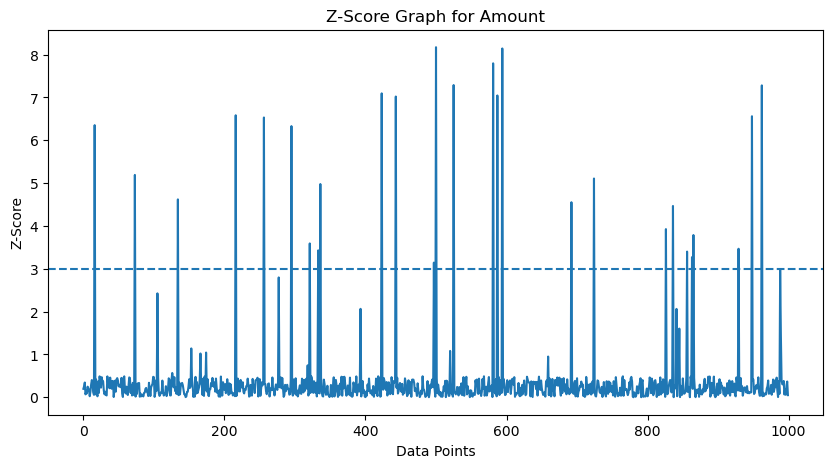

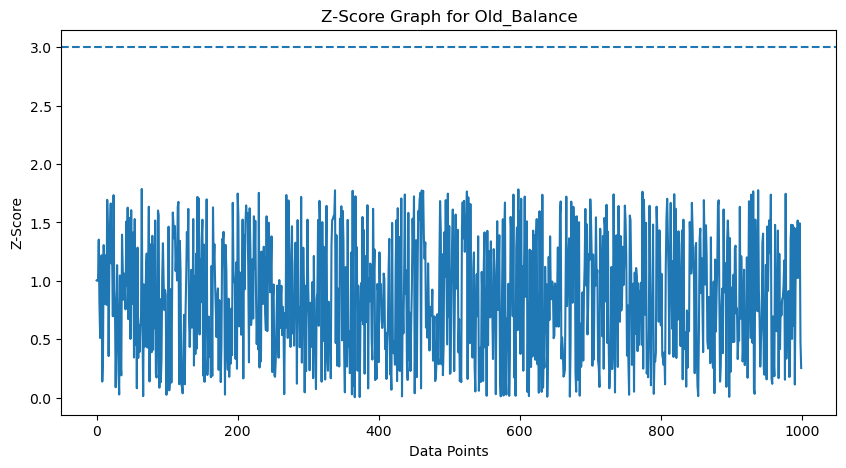

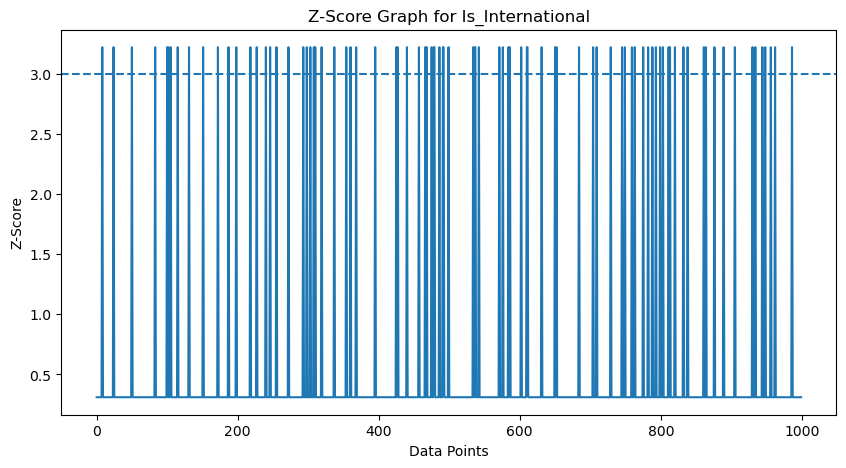

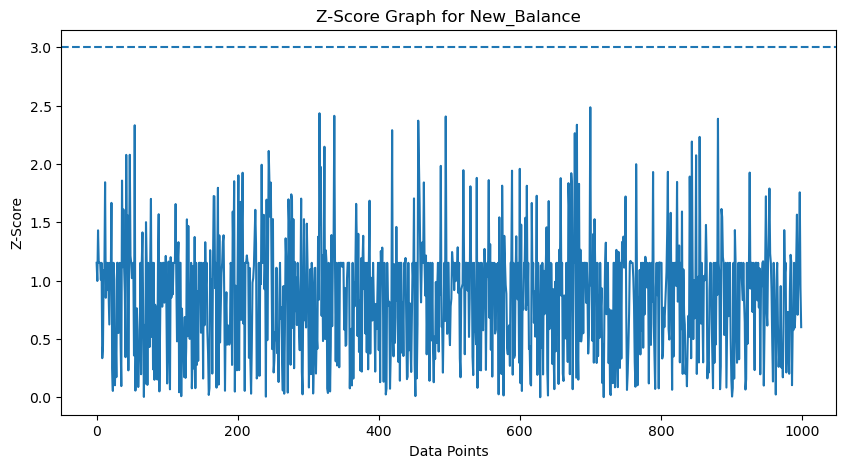

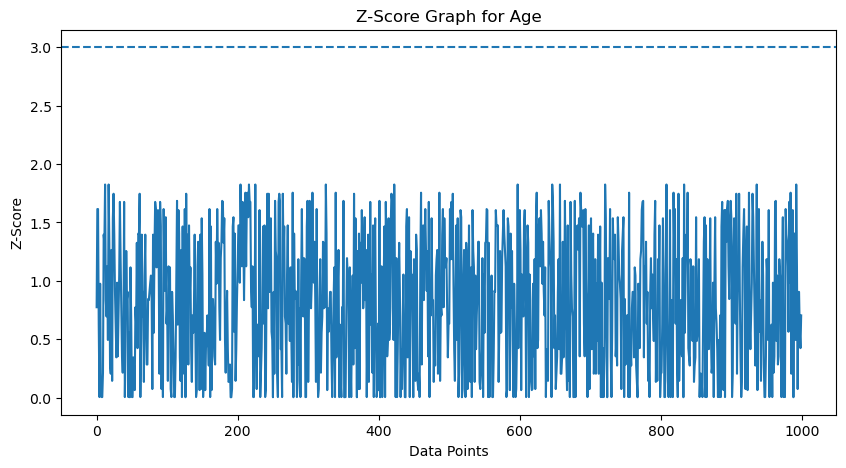

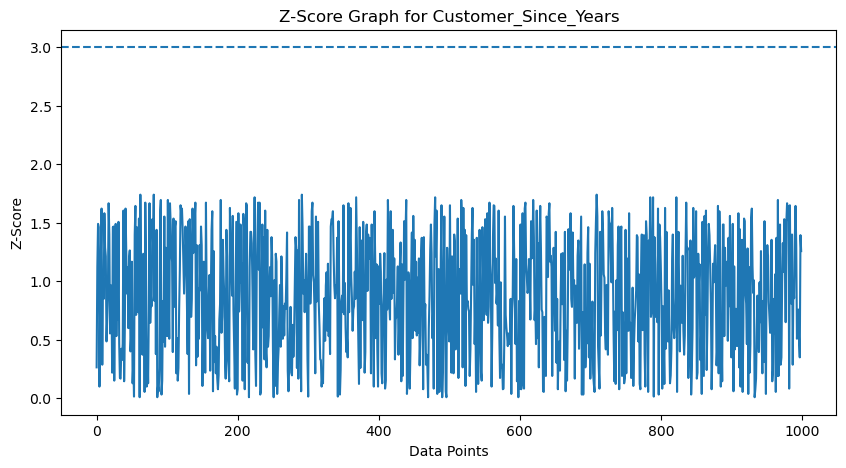

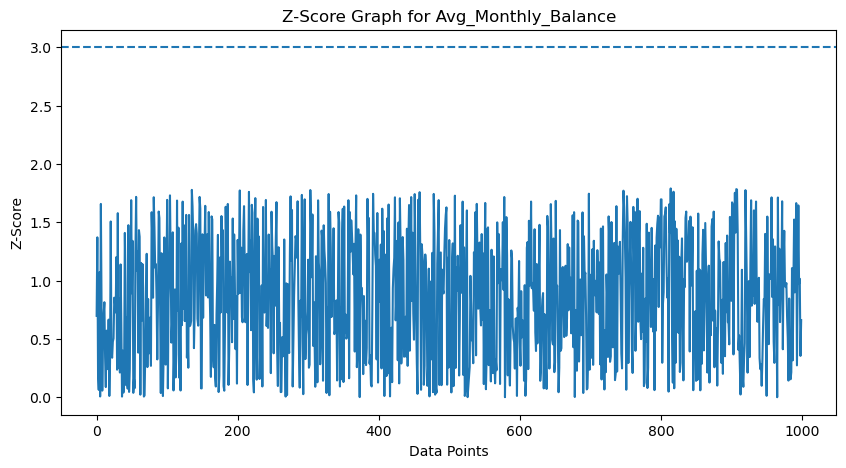


Outliers removed using Z-score!

Outliers removed using IQR!

Normalized Values (First 5 Rows):

     Amount  Old_Balance  Is_International  New_Balance       Age  \
0  0.346873     0.222944               0.0     0.000000  0.705882   
1  0.277557     0.224008               0.0     0.042717  0.941176   
2  0.172900     0.795407               0.0     0.709988  0.941176   
3  0.659995     0.123650               0.0     0.000000  0.313725   
4  0.425447     0.281136               0.0     0.000000  0.490585   

   Customer_Since_Years  Avg_Monthly_Balance  
0              0.566667             0.308909  
1              0.160000             0.118600  
2              0.926667             0.564589  
3              0.060000             0.524687  
4              0.460000             0.203497  


<Figure size 1000x500 with 0 Axes>

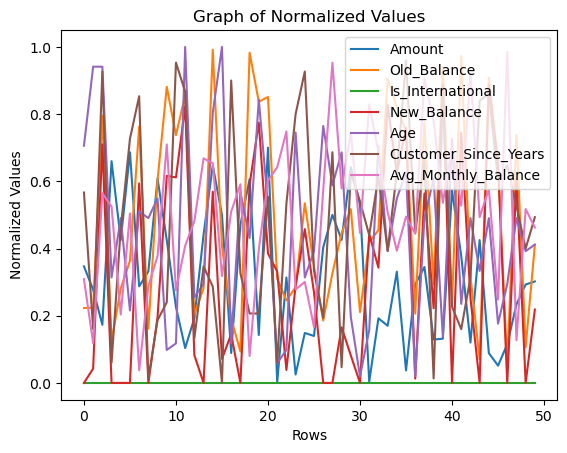


Standardized Values (First 5 Rows):

     Amount  Old_Balance  Is_International  New_Balance       Age  \
0 -0.113014    -1.001426               0.0    -1.143205  0.773528   
1 -0.448757    -0.997667               0.0    -0.986785  1.613503   
2 -0.955682     1.020531               0.0     1.456589  1.613503   
3  1.403647    -1.352134               0.0    -1.143205 -0.626430   
4  0.267573    -0.795889               0.0    -1.143205  0.004939   

   Customer_Since_Years  Avg_Monthly_Balance  
0              0.261773            -0.721355  
1             -1.104819            -1.400492  
2              1.471543             0.191068  
3             -1.440867             0.048672  
4             -0.096678            -1.097530  


<Figure size 1000x500 with 0 Axes>

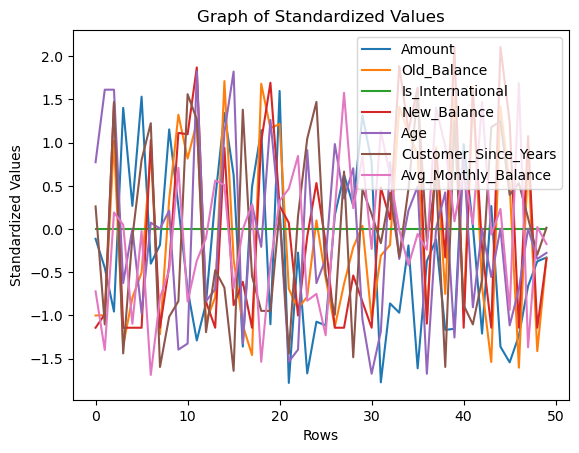

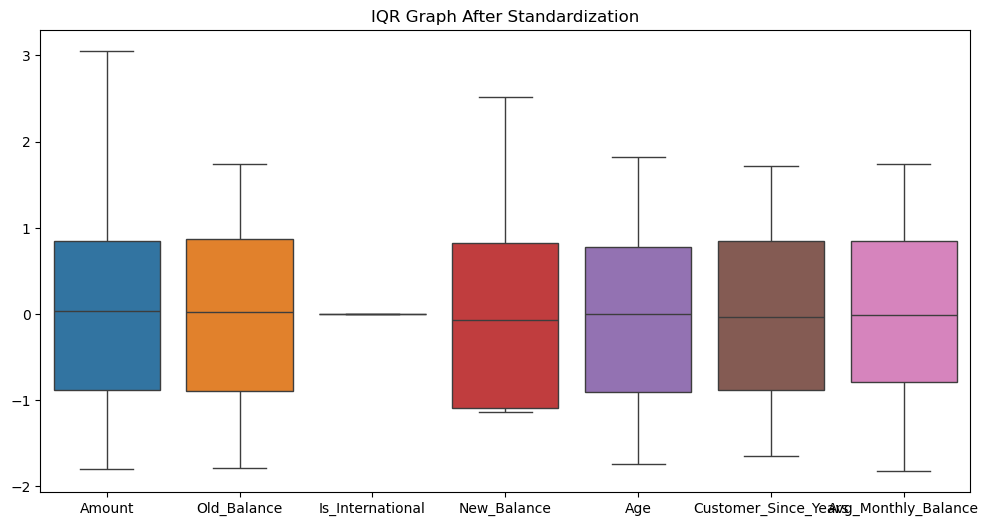

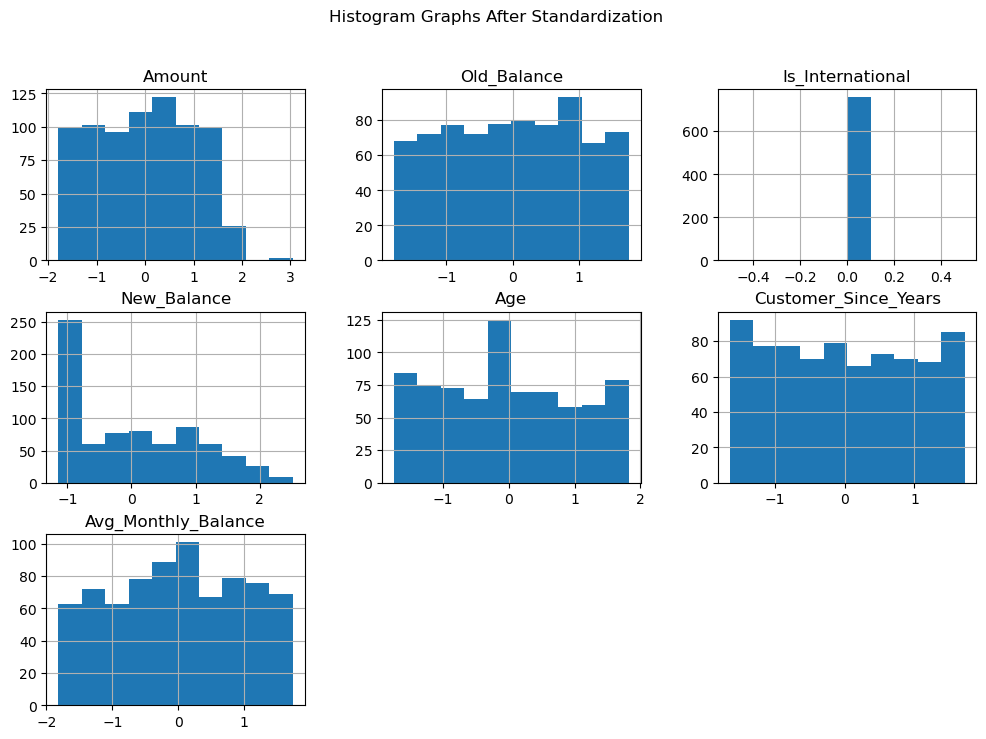

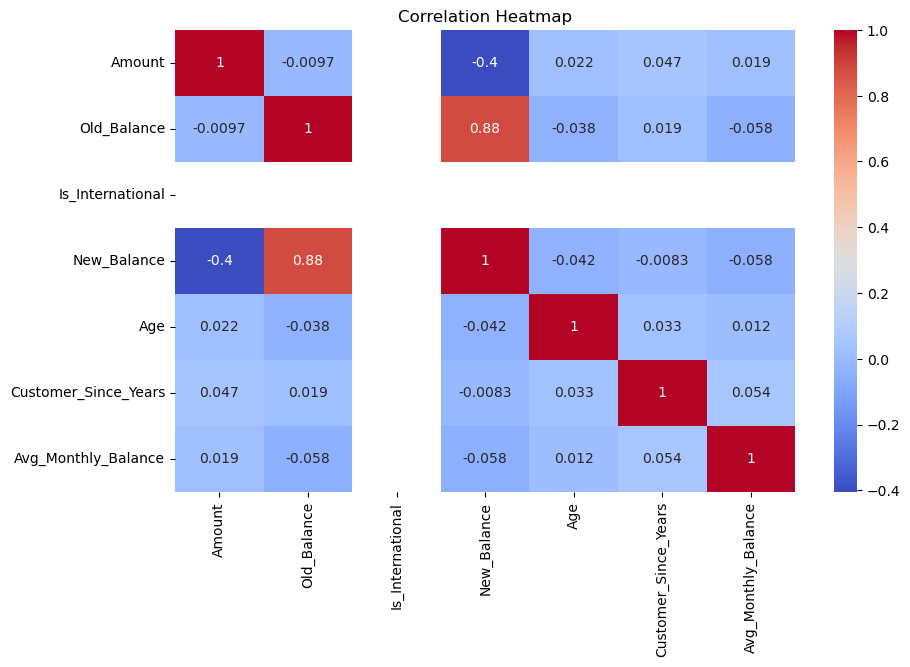


Final Cleaned Dataset with Normalized & Standardized Values Saved!


In [7]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.stats import zscore


# =========================================
# 2. LOAD DATASET
# =========================================
df = pd.read_csv("RAW_Dataset_With_Account_Number.csv")

print("\nDataset Loaded Successfully")
print("Shape:", df.shape)


# =========================================
# 3. BASIC EDA
# =========================================
print("\nFirst 5 Rows:\n", df.head())

print("\nDataset Info:\n")
print(df.info())

print("\nStatistical Summary:\n")
print(df.describe())


# =========================================
# 4. DISPLAY COLUMNS WITH NULL VALUES
# =========================================
print("\nColumns with NULL values:\n")
null_columns = df.columns[df.isnull().sum() > 0]
print(df[null_columns].isnull().sum())


# =========================================
# 5. HANDLE MISSING VALUES
# =========================================
for col in df.columns:
    
    if df[col].isnull().sum() > 0:
        
        # Numerical columns → mean
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].mean())
        
        # Categorical columns → mode
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values handled!")


# =========================================
# 6. REMOVE DUPLICATES (ONLY WHERE NOT ALLOWED)
# =========================================
if 'Transaction_ID' in df.columns:
    df = df.drop_duplicates(subset=['Transaction_ID'])

print("\nDuplicates removed only from Transaction_ID")
print("New Shape:", df.shape)


# =========================================
# 7. SELECT NUMERIC COLUMNS
# =========================================
num_cols = df.select_dtypes(include=np.number).columns


# =========================================
# 8. Z-SCORE GRAPH (BEFORE REMOVING OUTLIERS)
# =========================================
z_scores = np.abs(zscore(df[num_cols]))

z_df = pd.DataFrame(z_scores, columns=num_cols)

for col in num_cols:
    plt.figure(figsize=(10,5))
    plt.plot(z_df[col])
    plt.axhline(y=3, linestyle='--')
    plt.title("Z-Score Graph for " + col)
    plt.xlabel("Data Points")
    plt.ylabel("Z-Score")
    plt.show()


# =========================================
# 9. OUTLIER DETECTION USING Z-SCORE
# =========================================
df = df[(z_scores < 3).all(axis=1)]

print("\nOutliers removed using Z-score!")


# =========================================
# 10. OUTLIER DETECTION USING IQR
# =========================================
for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("\nOutliers removed using IQR!")


# =========================================
# 11. NORMALIZATION (MinMax Scaling)
# =========================================
scaler = MinMaxScaler()
normalized_values = scaler.fit_transform(df[num_cols])

df_normalized = pd.DataFrame(normalized_values, columns=num_cols)

print("\nNormalized Values (First 5 Rows):\n")
print(df_normalized.head())


# ----- Graph for Normalized Values -----
plt.figure(figsize=(10,5))
df_normalized.head(50).plot()
plt.title("Graph of Normalized Values")
plt.xlabel("Rows")
plt.ylabel("Normalized Values")
plt.show()


# =========================================
# 12. STANDARDIZATION
# =========================================
std_scaler = StandardScaler()
standardized_values = std_scaler.fit_transform(df[num_cols])

df_standardized = pd.DataFrame(standardized_values, columns=num_cols)

print("\nStandardized Values (First 5 Rows):\n")
print(df_standardized.head())


# ----- Graph for Standardized Values -----
plt.figure(figsize=(10,5))
df_standardized.head(50).plot()
plt.title("Graph of Standardized Values")
plt.xlabel("Rows")
plt.ylabel("Standardized Values")
plt.show()


# =========================================
# 13. REPLACE ORIGINAL NUMERIC DATA
# (Final dataset will contain standardized values)
# =========================================
df[num_cols] = df_standardized


# =========================================
# 14. IQR GRAPH (BOXPLOT)
# =========================================
plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.title("IQR Graph After Standardization")
plt.show()


# =========================================
# 15. HISTOGRAM GRAPH
# =========================================
df[num_cols].hist(figsize=(12,8))
plt.suptitle("Histogram Graphs After Standardization")
plt.show()


# =========================================
# 16. CORRELATION HEATMAP
plt.figure(figsize=(10, 6))

# Use numeric_only=True to ignore text/string columns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()


# =========================================
# 17. SAVE CLEANED DATASET
# =========================================
df.to_csv("Cleaned_Dataset_Normalized_Standardized.csv", index=False)

print("\nFinal Cleaned Dataset with Normalized & Standardized Values Saved!")

In [3]:
import os
print(os.getcwd())

C:\Users\HP
